In [1]:
!wget -O /content/graph_opt.pb https://github.com/quanhua92/human-pose-estimation-opencv/raw/master/graph_opt.pb

--2026-09-19 09:19:57--  https://github.com/quanhua92/human-pose-estimation-opencv/raw/master/graph_opt.pb
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/quanhua92/human-pose-estimation-opencv/master/graph_opt.pb [following]
--2026-09-19 09:19:57--  https://raw.githubusercontent.com/quanhua92/human-pose-estimation-opencv/master/graph_opt.pb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7804434 (7.4M) [application/octet-stream]
Saving to: ‘/content/graph_opt.pb’

/content/graph_opt. 100%[===================>]   7.44M  --.-KB/s    in 0.09s   

2026-09-19 09:19:58 (87.5 MB/s) - ‘/content/graph_o

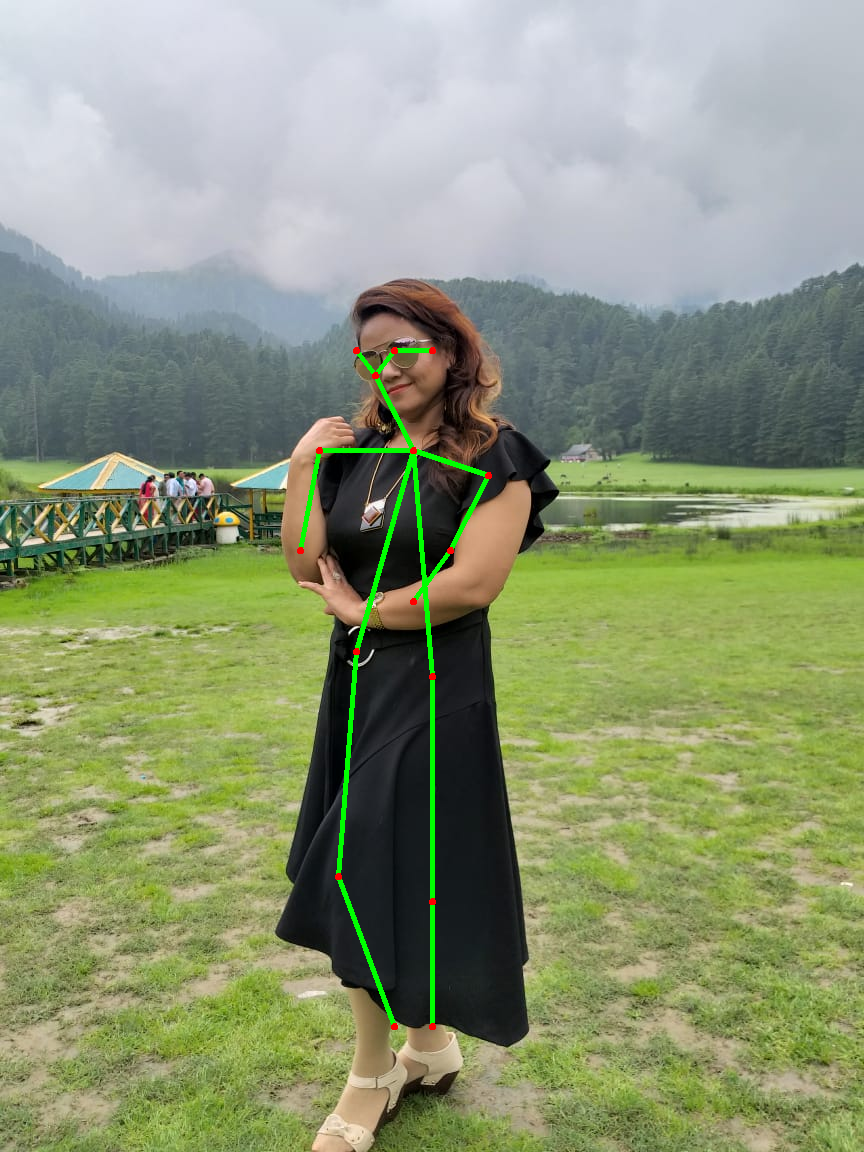

In [3]:
# Human Pose Detection using OpenCV DNN
# Model: COCO-trained 2D human pose model (OpenPose-style output)
# Designed for Google Colab

import cv2 as cv
from google.colab.patches import cv2_imshow
from pathlib import Path

# -----------------------------
# 1. Body keypoints and skeleton
# -----------------------------
BODY_PARTS = {
    "Nose": 0, "Neck": 1, "RShoulder": 2, "RElbow": 3, "RWrist": 4,
    "LShoulder": 5, "LElbow": 6, "LWrist": 7, "RHip": 8, "RKnee": 9,
    "RAnkle": 10, "LHip": 11, "LKnee": 12, "LAnkle": 13,
    "REye": 14, "LEye": 15, "REar": 16, "LEar": 17,
    "Background": 18
}

POSE_PAIRS = [
    ["Neck", "RShoulder"], ["Neck", "LShoulder"],
    ["RShoulder", "RElbow"], ["RElbow", "RWrist"],
    ["LShoulder", "LElbow"], ["LElbow", "LWrist"],
    ["Neck", "RHip"], ["RHip", "RKnee"], ["RKnee", "RAnkle"],
    ["Neck", "LHip"], ["LHip", "LKnee"], ["LKnee", "LAnkle"],
    ["Neck", "Nose"], ["Nose", "REye"], ["REye", "REar"],
    ["Nose", "LEye"], ["LEye", "LEar"]
]

# -----------------------------
# 2. Configuration
# -----------------------------
MODEL_PATH = "/content/graph_opt.pb"       # TensorFlow frozen graph
IMAGE_PATH = "/content/20180729_180105.jpg"

IN_WIDTH = 368
IN_HEIGHT = 368
THRESHOLD = 0.20

# -----------------------------
# 3. Validate files
# -----------------------------
if not Path(MODEL_PATH).exists():
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}\n"
        "Upload the TensorFlow pose model (.pb) to Colab first."
    )

if not Path(IMAGE_PATH).exists():
    raise FileNotFoundError(f"Input image not found: {IMAGE_PATH}")

# -----------------------------
# 4. Load the pre-trained model
# -----------------------------
net = cv.dnn.readNetFromTensorflow(MODEL_PATH)

# -----------------------------
# 5. Read input image
# -----------------------------
image = cv.imread(IMAGE_PATH)

if image is None:
    raise ValueError("OpenCV could not read the input image.")

frame_width = image.shape[1]
frame_height = image.shape[0]

# -----------------------------
# 6. Pre-process and inference
# -----------------------------
blob = cv.dnn.blobFromImage(
    image,
    scalefactor=1.0,
    size=(IN_WIDTH, IN_HEIGHT),
    mean=(127.5, 127.5, 127.5),
    swapRB=True,
    crop=False
)

net.setInput(blob)
output = net.forward()

# The COCO pose model has 19 output maps:
# 18 body-part maps + 1 background map.
output = output[:, :19, :, :]

# -----------------------------
# 7. Detect keypoints
# -----------------------------
points = []

for i in range(len(BODY_PARTS)):
    heat_map = output[0, i, :, :]

    _, confidence, _, point = cv.minMaxLoc(heat_map)

    x = (frame_width * point[0]) / output.shape[3]
    y = (frame_height * point[1]) / output.shape[2]

    if confidence > THRESHOLD:
        points.append((int(x), int(y)))
    else:
        points.append(None)

# -----------------------------
# 8. Draw skeleton
# -----------------------------
for pair in POSE_PAIRS:
    part_from, part_to = pair

    id_from = BODY_PARTS[part_from]
    id_to = BODY_PARTS[part_to]

    if points[id_from] is not None and points[id_to] is not None:
        cv.line(
            image,
            points[id_from],
            points[id_to],
            (0, 255, 0),
            3
        )

        cv.ellipse(
            image,
            points[id_from],
            (3, 3),
            0, 0, 360,
            (0, 0, 255),
            cv.FILLED
        )

        cv.ellipse(
            image,
            points[id_to],
            (3, 3),
            0, 0, 360,
            (0, 0, 255),
            cv.FILLED
        )

# -----------------------------
# 9. Display result
# -----------------------------
cv2_imshow(image)
